In [1]:
# generate example data

import numpy as np
import pandas as pd

def ocv(soc):
    return 3.0 + 1.2 * soc - 0.1 * np.sin(np.pi * soc)

def generate_cycle_thevenin(t0, R0, R1, C1, dt=1.0):
    capacity = 1.0  # Ah

    t, v, i, soc_list = [], [], [], []

    time = t0
    soc = 0.1
    vrc = 0.0

    def step(current):
        nonlocal soc, vrc, time

        soc += current * dt / 3600 / capacity
        soc = np.clip(soc, 0, 1)

        # RC更新
        dvrc = (-vrc / (R1 * C1) + current / C1) * dt
        vrc += dvrc

        vt = ocv(soc) + current * R0 + vrc

        t.append(time)
        v.append(vt)
        i.append(current)
        soc_list.append(soc)

        time += dt

    # --- CC充電 ---
    while True:
        step(1.0)
        if v[-1] >= 4.2:
            break

    # --- CV充電 ---
    Vset = 4.2
    while True:
        current = (Vset - ocv(soc) - vrc) / R0
        current = np.clip(current, 0.0, 1.0)
        step(current)

        if current < 0.05:
            break

    # --- 休止 ---
    for _ in range(500):
        step(0.0)

    # --- CC放電 ---
    while True:
        step(-1.0)
        if v[-1] <= 3.0:
            break

    # --- 休止 ---
    for _ in range(500):
        step(0.0)

    return pd.DataFrame({
        "time_s": t,
        "voltage_V": v,
        "current_A": i,
        "soc": soc_list
    })


# ===== サイクル生成 =====

cycles = []
t0 = 0

# 初期パラメータ
R0_base = 0.03
R1_base = 0.02
C1 = 2000.0

n_cycles = 100

for k in range(n_cycles):
    # 劣化：抵抗増加
    R0 = R0_base * (1 + 0.05 * k)   # サイクルごとに+5%
    R1 = R1_base * (1 + 0.1 * k)   # 緩和も悪化

    df_cycle = generate_cycle_thevenin(t0, R0, R1, C1)
    df_cycle['cycle'] = k + 1

    cycles.append(df_cycle)
    t0 = df_cycle["time_s"].iloc[-1] + 1

df = pd.concat(cycles, ignore_index=True)

# ノイズ追加
rng = np.random.default_rng(0)
df["voltage_V"] += rng.normal(0, 0.001, len(df))

print("points:", len(df))

points: 825874


In [2]:
from batanalysis.data import ChargeDischargeData
from batanalysis import processing, plotting
for c in ('time', 'voltage', 'current'):
    print(ChargeDischargeData.schema[c])

ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float64, base_unit='s')
ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float32, base_unit='V')
ColumnSpec(role=<Role.EXTENSIVE: 1>, dtype=Float32, base_unit='mA')


In [3]:
data = ChargeDischargeData(
    {'time': df['time_s'], 'voltage': df['voltage_V'], 'current': df['current_A']*1000, 'cycle': df['cycle']}
)
data = data.downsample(10)
processing.detect_states(data, atol=10.0)
processing.detect_steps(data)
processing.integrate_capacity(data)
processing.integrate_energy(data)

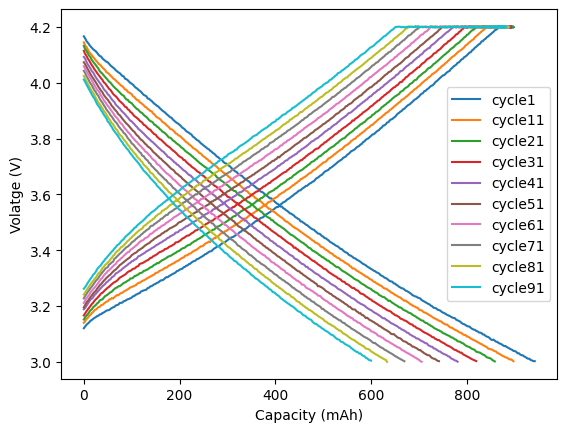

In [4]:
import matplotlib.pyplot as plt

plt.figure()
for i in data.cycle.unique(maintain_order=True):
    if i% 10 == 1:
        plotting.ChargeDischarge(cycle=i).plot(data, plt.gca(), label=f'cycle{i}')
plt.legend()